**Rekomendasi Lagu Berdasarkan Prefensi Pengguna di Spotify**

---



**[20221037031176 – Revinda Visma Novatalia]**


# **DATASET**

Dataset diambil dari kaggle [Dataset Rekomendasi Lagu Spotify](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)





Dataset yang tersimpan di GitHub akan diunduh terlebih dahulu dengan menjalankan perintah pada cell berikut :

In [3]:
# Simpan ke file CSV di path lokal Colab
url = 'https://raw.githubusercontent.com/Revinda18/project-Data-Mining/refs/heads/main/dataset.csv'

# Baca dataset langsung dari URL
df = pd.read_csv(url)

# Simpan dataset ke path lokal di Colab
save_path = '/content/dataset.csv'
df.to_csv(save_path, index=False)

print(f"Dataset berhasil disimpan ke: {save_path}")

Dataset berhasil disimpan ke: /content/dataset.csv


#**IMPORT LIBRARY**

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.preprocessing import StandardScaler
import math

#**LOAD DATASET**

In [4]:
# Membaca file CSV dari path lokal di Colab
df = pd.read_csv('/content/dataset.csv')

# Menampilkan semua kolom
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Menampilkan 10 data teratas
top_10 = df.head(10)
print("10 data teratas:")
print(top_10)


10 data teratas:
   Unnamed: 0                track_id                               artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV                           Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A                          Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b                Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx                          Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K                      Chord Overstreet   
5           5  01MVOl9KtVTNfFiBU9I7dc                          Tyrone Wells   
6           6  6Vc5wAMmXdKIAM7WUoEb7N  A Great Big World;Christina Aguilera   
7           7  1EzrEOXmMH3G43AXT1y7pA                            Jason Mraz   
8           8  0IktbUcnAGrvD03AWnz3Q8             Jason Mraz;Colbie Caillat   
9           9  7k9GuJYLp2AzqokyEdwEw2                        Ross Copperman   

                                          album_name  \
0                                             Comedy   
1

#**Exploratory Data Analysis (EDA)**


EDA (Exploratory Data Analysis) adalah proses awal dalam analisis data untuk memahami struktur, pola, dan hubungan dalam dataset sebelum melakukan analisis lebih lanjut. EDA bertujuan untuk mengidentifikasi tren, mendeteksi outlier, memeriksa distribusi data, dan memeriksa hubungan antar variabel.

## Dimensi dan Tipe Data

In [5]:
print("=== INFORMASI UMUM DATASET ===")
print(f"Jumlah baris dan kolom: {df.shape}")
print("\nTipe data tiap kolom:")
print(df.dtypes)

=== INFORMASI UMUM DATASET ===
Jumlah baris dan kolom: (114000, 21)

Tipe data tiap kolom:
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


## Statistik Deskriptif Fitur Numerik

In [6]:
print("\n=== STATISTIK DESKRIPTIF FITUR NUMERIK ===")
print(df.describe())


=== STATISTIK DESKRIPTIF FITUR NUMERIK ===
          Unnamed: 0     popularity   duration_ms   danceability  \
count  114000.000000  114000.000000  1.140000e+05  114000.000000   
mean    56999.500000      33.238535  2.280292e+05       0.566800   
std     32909.109681      22.305078  1.072977e+05       0.173542   
min         0.000000       0.000000  0.000000e+00       0.000000   
25%     28499.750000      17.000000  1.740660e+05       0.456000   
50%     56999.500000      35.000000  2.129060e+05       0.580000   
75%     85499.250000      50.000000  2.615060e+05       0.695000   
max    113999.000000     100.000000  5.237295e+06       0.985000   

              energy            key       loudness           mode  \
count  114000.000000  114000.000000  114000.000000  114000.000000   
mean        0.641383       5.309140      -8.258960       0.637553   
std         0.251529       3.559987       5.029337       0.480709   
min         0.000000       0.000000     -49.531000       0.000000  

## Statistik Deskriptif Fitur Kategorikal

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("\n=== STATISTIK FITUR KATEGORIK ===")
for col in cat_cols:
    print(f"\nFrekuensi nilai pada kolom '{col}':")
    print(df[col].value_counts().head(10))


=== STATISTIK FITUR KATEGORIK ===

Frekuensi nilai pada kolom 'track_id':
track_id
6S3JlDAGk3uu3NtZbPnuhS    9
2Ey6v4Sekh3Z0RUSISRosD    8
2kkvB3RNRzwjFdGhaUA0tz    8
4WJTKbNJQ41zXnb84jSWaj    7
2aaClnypAakdAmLw74JXxB    7
7tbzfR8ZvZzJEzy6v0d6el    7
5ZsAhuQ24mWHiduaxJqnhW    7
0YLSjVxSb5FT1Bo8Tnxr8j    7
2qgXrzJsry4KgYoJCpuaul    7
3dJjsWCy6ZwMfw5NbD226G    7
Name: count, dtype: int64

Frekuensi nilai pada kolom 'artists':
artists
The Beatles        279
George Jones       271
Stevie Wonder      236
Linkin Park        224
Ella Fitzgerald    222
Prateek Kuhad      217
Feid               202
Chuck Berry        190
Håkan Hellström    183
OneRepublic        181
Name: count, dtype: int64

Frekuensi nilai pada kolom 'album_name':
album_name
Alternative Christmas 2022     195
Feliz Cumpleaños con Perreo    184
Metal                          143
Halloween con perreito         123
Halloween Party 2022           115
The Complete Hank Williams     111
Fiesta portatil                110
Frescura 

##Missing Value

In [8]:
print("Missing Value per Kolom:")
print(df.isnull().sum())

Missing Value per Kolom:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


## Distribusi Popularitas

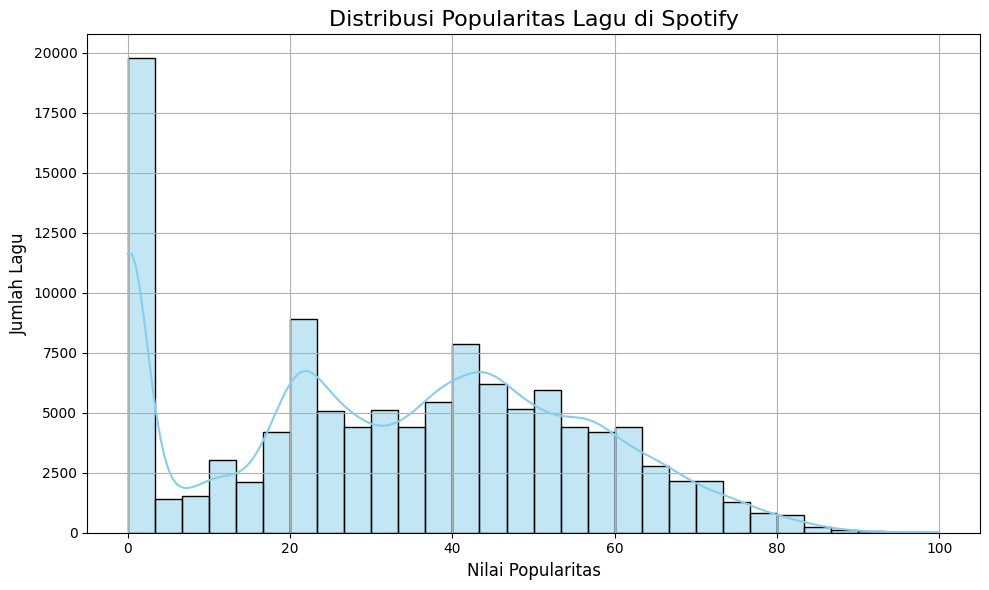

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df['popularity'], bins=30, kde=True, color='skyblue')
plt.title('Distribusi Popularitas Lagu di Spotify', fontsize=16)
plt.xlabel('Nilai Popularitas', fontsize=12)
plt.ylabel('Jumlah Lagu', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

## Korelasi Fitur Numerik


Nilai korelasi berkisar antara -1 hingga 1:
*   1 = hubungan sangat kuat dan searah
*   0 = tidak ada hubungan
*   -1 = hubungan sangat kuat dan berlawanan arah



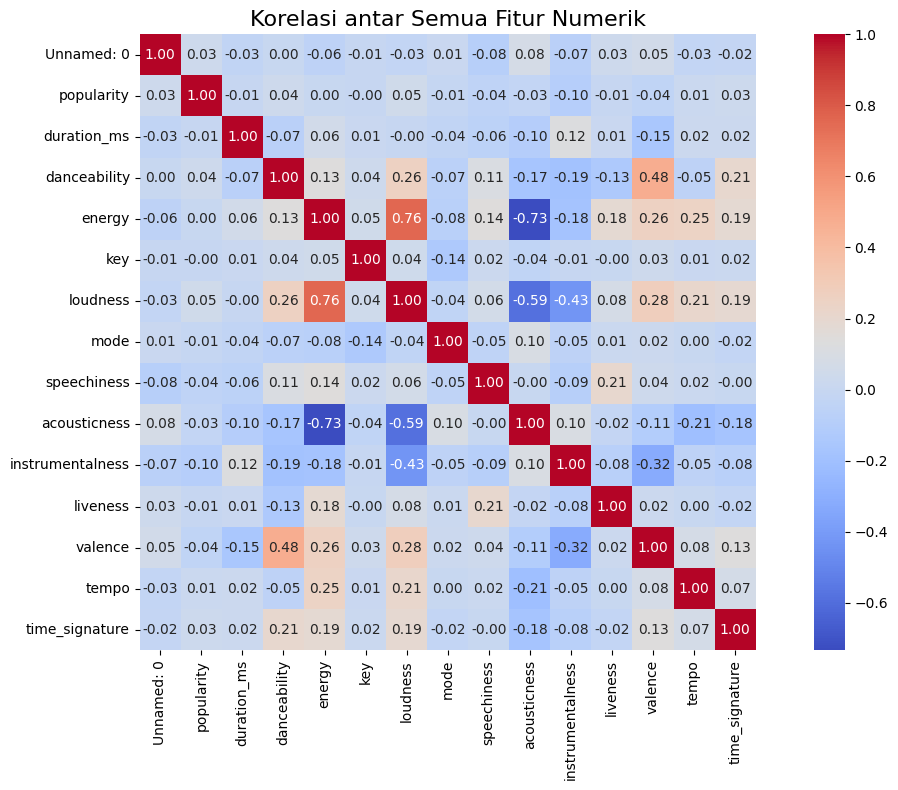

In [10]:
# Memilih hanya kolom numerik
df_numeric = df.select_dtypes(include=['number'])

# Menghitung korelasi antar kolom numerik
correlation_matrix = df_numeric.corr()

# Plot heatmap korelasi
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Korelasi antar Semua Fitur Numerik', fontsize=16)
plt.tight_layout()
plt.show()

## Check Outlier

<ipython-input-11-2378877752>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df_numeric[column], palette='Set2')  # boxplot horizontal
<ipython-input-11-2378877752>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df_numeric[column], palette='Set2')  # boxplot horizontal
<ipython-input-11-2378877752>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df_numeric[column], palette='Set2')  # boxplot horizontal
<ipython-input-11-2378877752>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed 

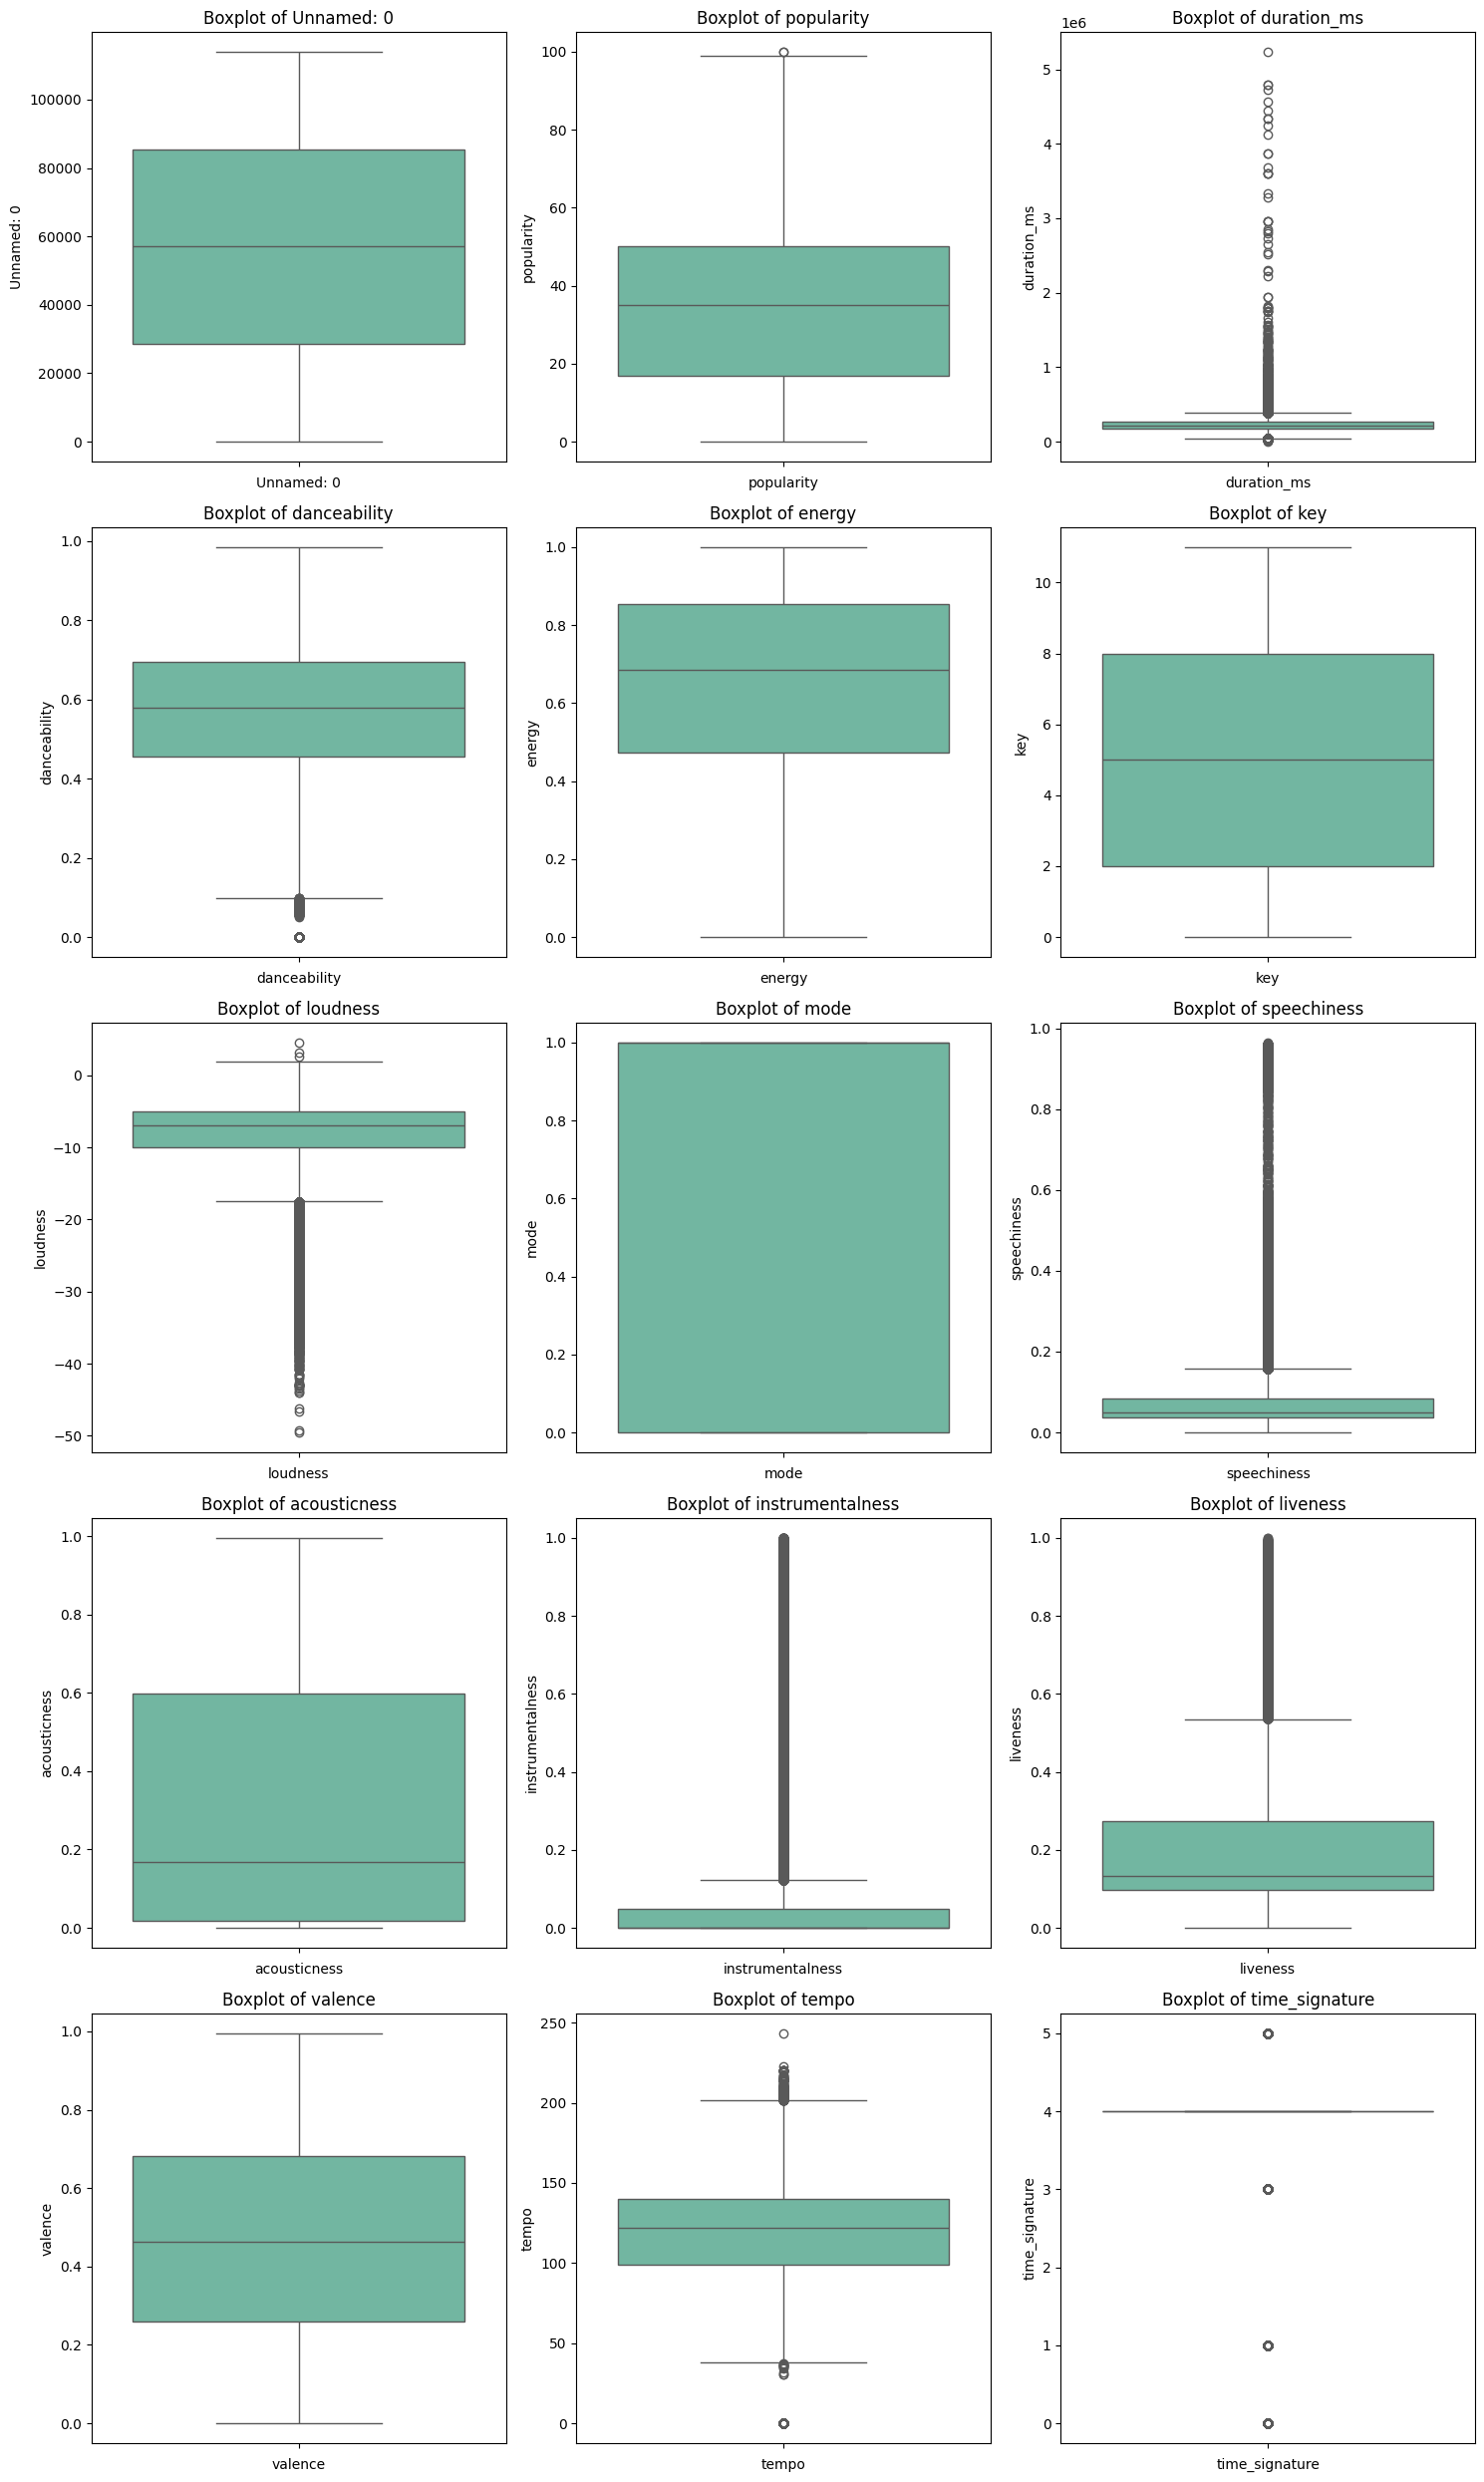

In [11]:
# Memilih kolom numerik
df_numeric = df.select_dtypes(include=['number'])

num_features = len(df_numeric.columns)
cols = 3  # jumlah kolom per baris
rows = math.ceil(num_features / cols)  # hitung baris yang diperlukan

plt.figure(figsize=(5 * cols, 5 * rows))  # ukuran figure disesuaikan

for i, column in enumerate(df_numeric.columns):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df_numeric[column], palette='Set2')  # boxplot horizontal
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)

plt.tight_layout()
plt.show()

## Jumlah Lagu Berdasarkan Genre

<ipython-input-12-1606635171>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='Set3')


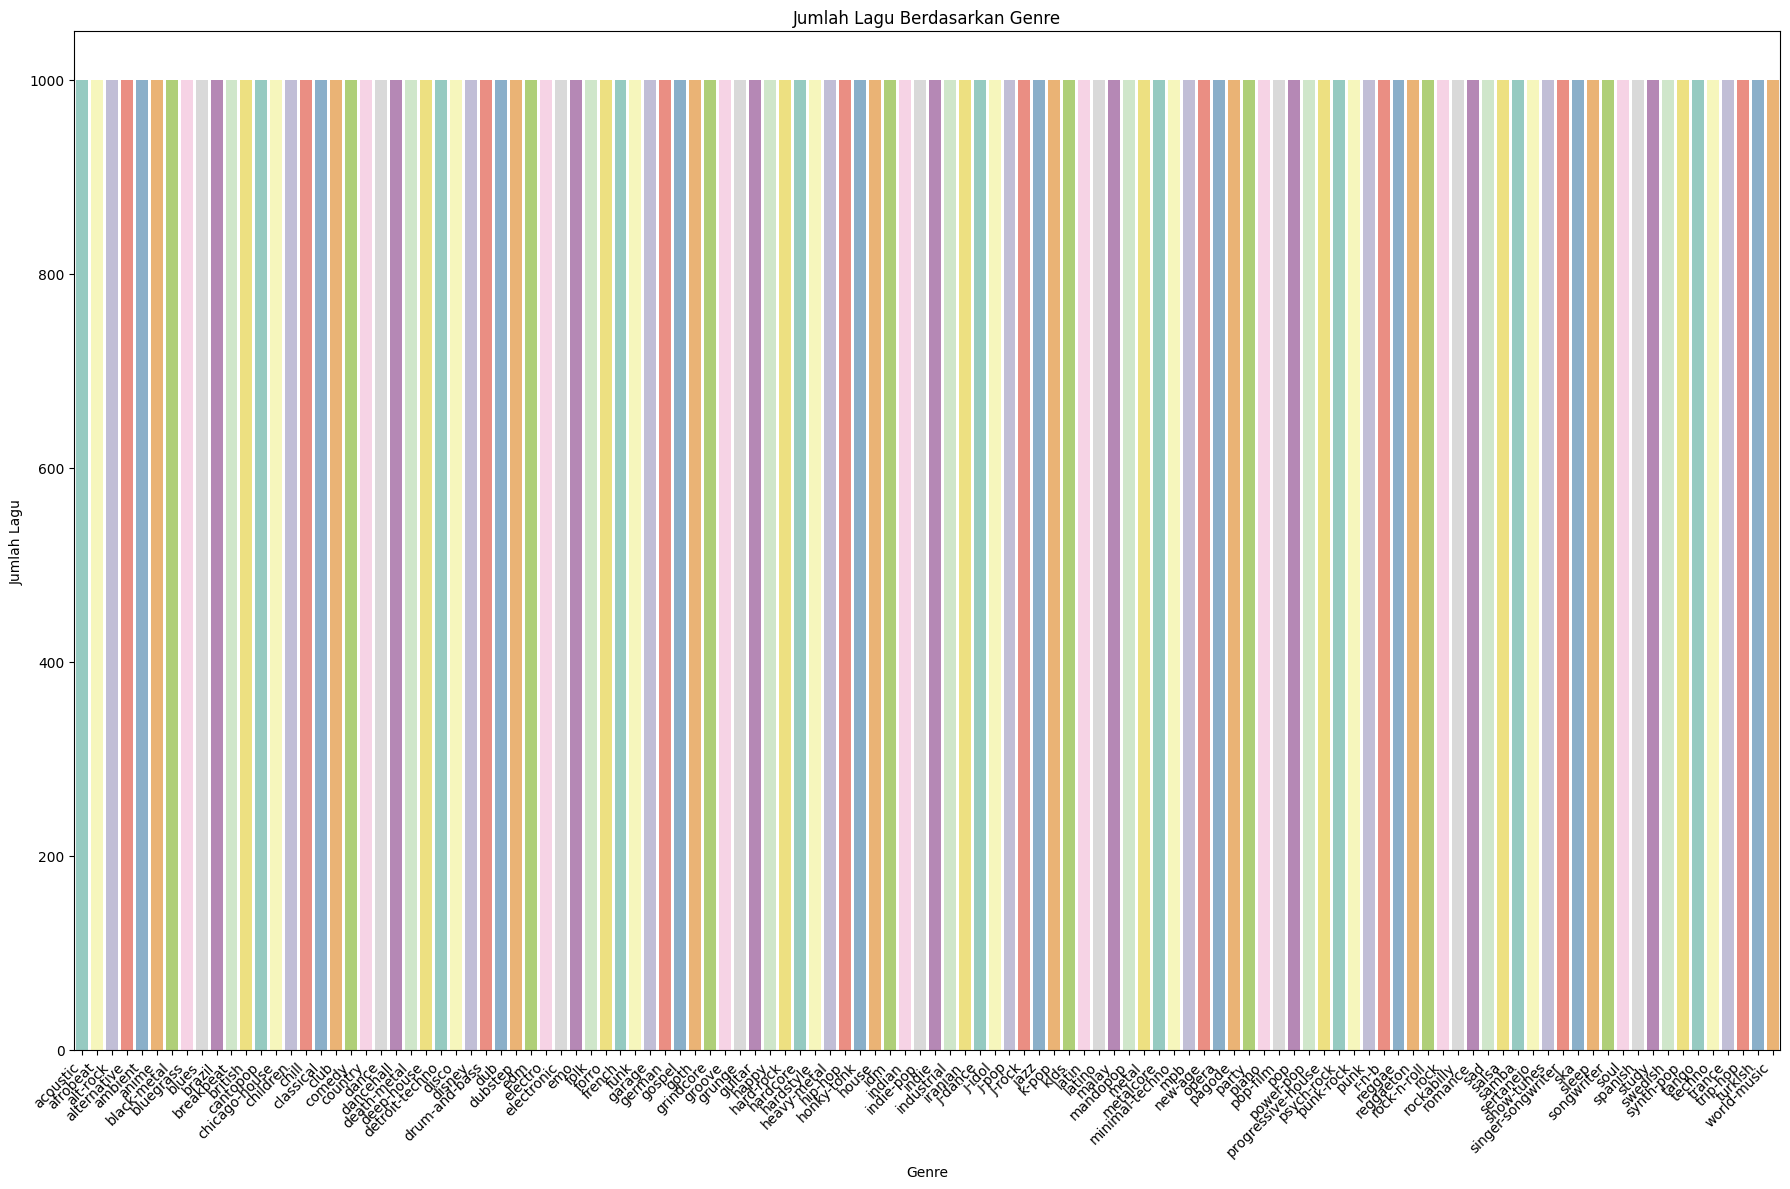

In [12]:
# Menghitung jumlah lagu untuk setiap genre
genre_counts = df['track_genre'].value_counts()

# Menyesuaikan grafik batang dengan memberikan lebih banyak ruang antar batang
plt.figure(figsize=(18, 12))
sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='Set3')
plt.title('Jumlah Lagu Berdasarkan Genre')
plt.xlabel('Genre')
plt.ylabel('Jumlah Lagu')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Jumlah Lagu Berdasarkan Popularitas

<ipython-input-13-3202554498>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=popularity_counts.index, y=popularity_counts.values, palette='Set2')


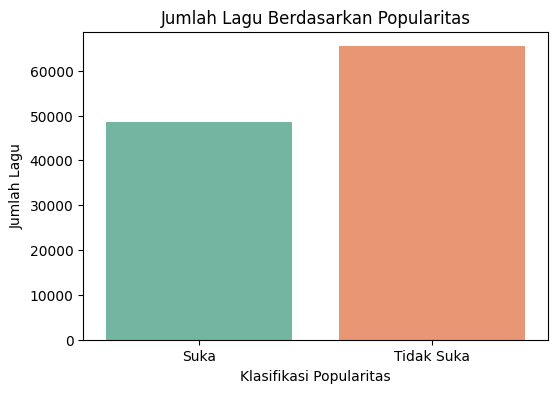

In [13]:
# Klasifikasi berdasarkan popularitas: Suka, Sedang, Tidak Suka
def classify_popularity(score):
    if score >= 40:
        return 'Suka'
    else:
        return 'Tidak Suka'

df['popularity_class'] = df['popularity'].apply(classify_popularity)

# Menghitung jumlah lagu berdasarkan klasifikasi popularitas
popularity_counts = df['popularity_class'].value_counts().reindex(['Suka', 'Tidak Suka'])

# Membuat bar plot
plt.figure(figsize=(6, 4))
sns.barplot(x=popularity_counts.index, y=popularity_counts.values, palette='Set2')
plt.title('Jumlah Lagu Berdasarkan Popularitas')
plt.xlabel('Klasifikasi Popularitas')
plt.ylabel('Jumlah Lagu')
plt.show()

# DATA CLEANING

In [14]:
# Load data
df = pd.read_csv("dataset.csv")

# Menghapus baris duplikat
df_cleaned = df.drop_duplicates()

# Menampilkan jumlah duplikat setelah dihapus
print(f"Jumlah duplikat setelah dihapus: {df_cleaned.duplicated().sum()}")

Jumlah duplikat setelah dihapus: 0


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
<ipython-input-15-3795370916>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_transformed[column], palette='Set2')
<ipython-input-15-3795370916>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_transformed[column], palette='Set2')
<ipython-input-15-3795370916>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df_transformed[column], palette='Set2')
<ipytho

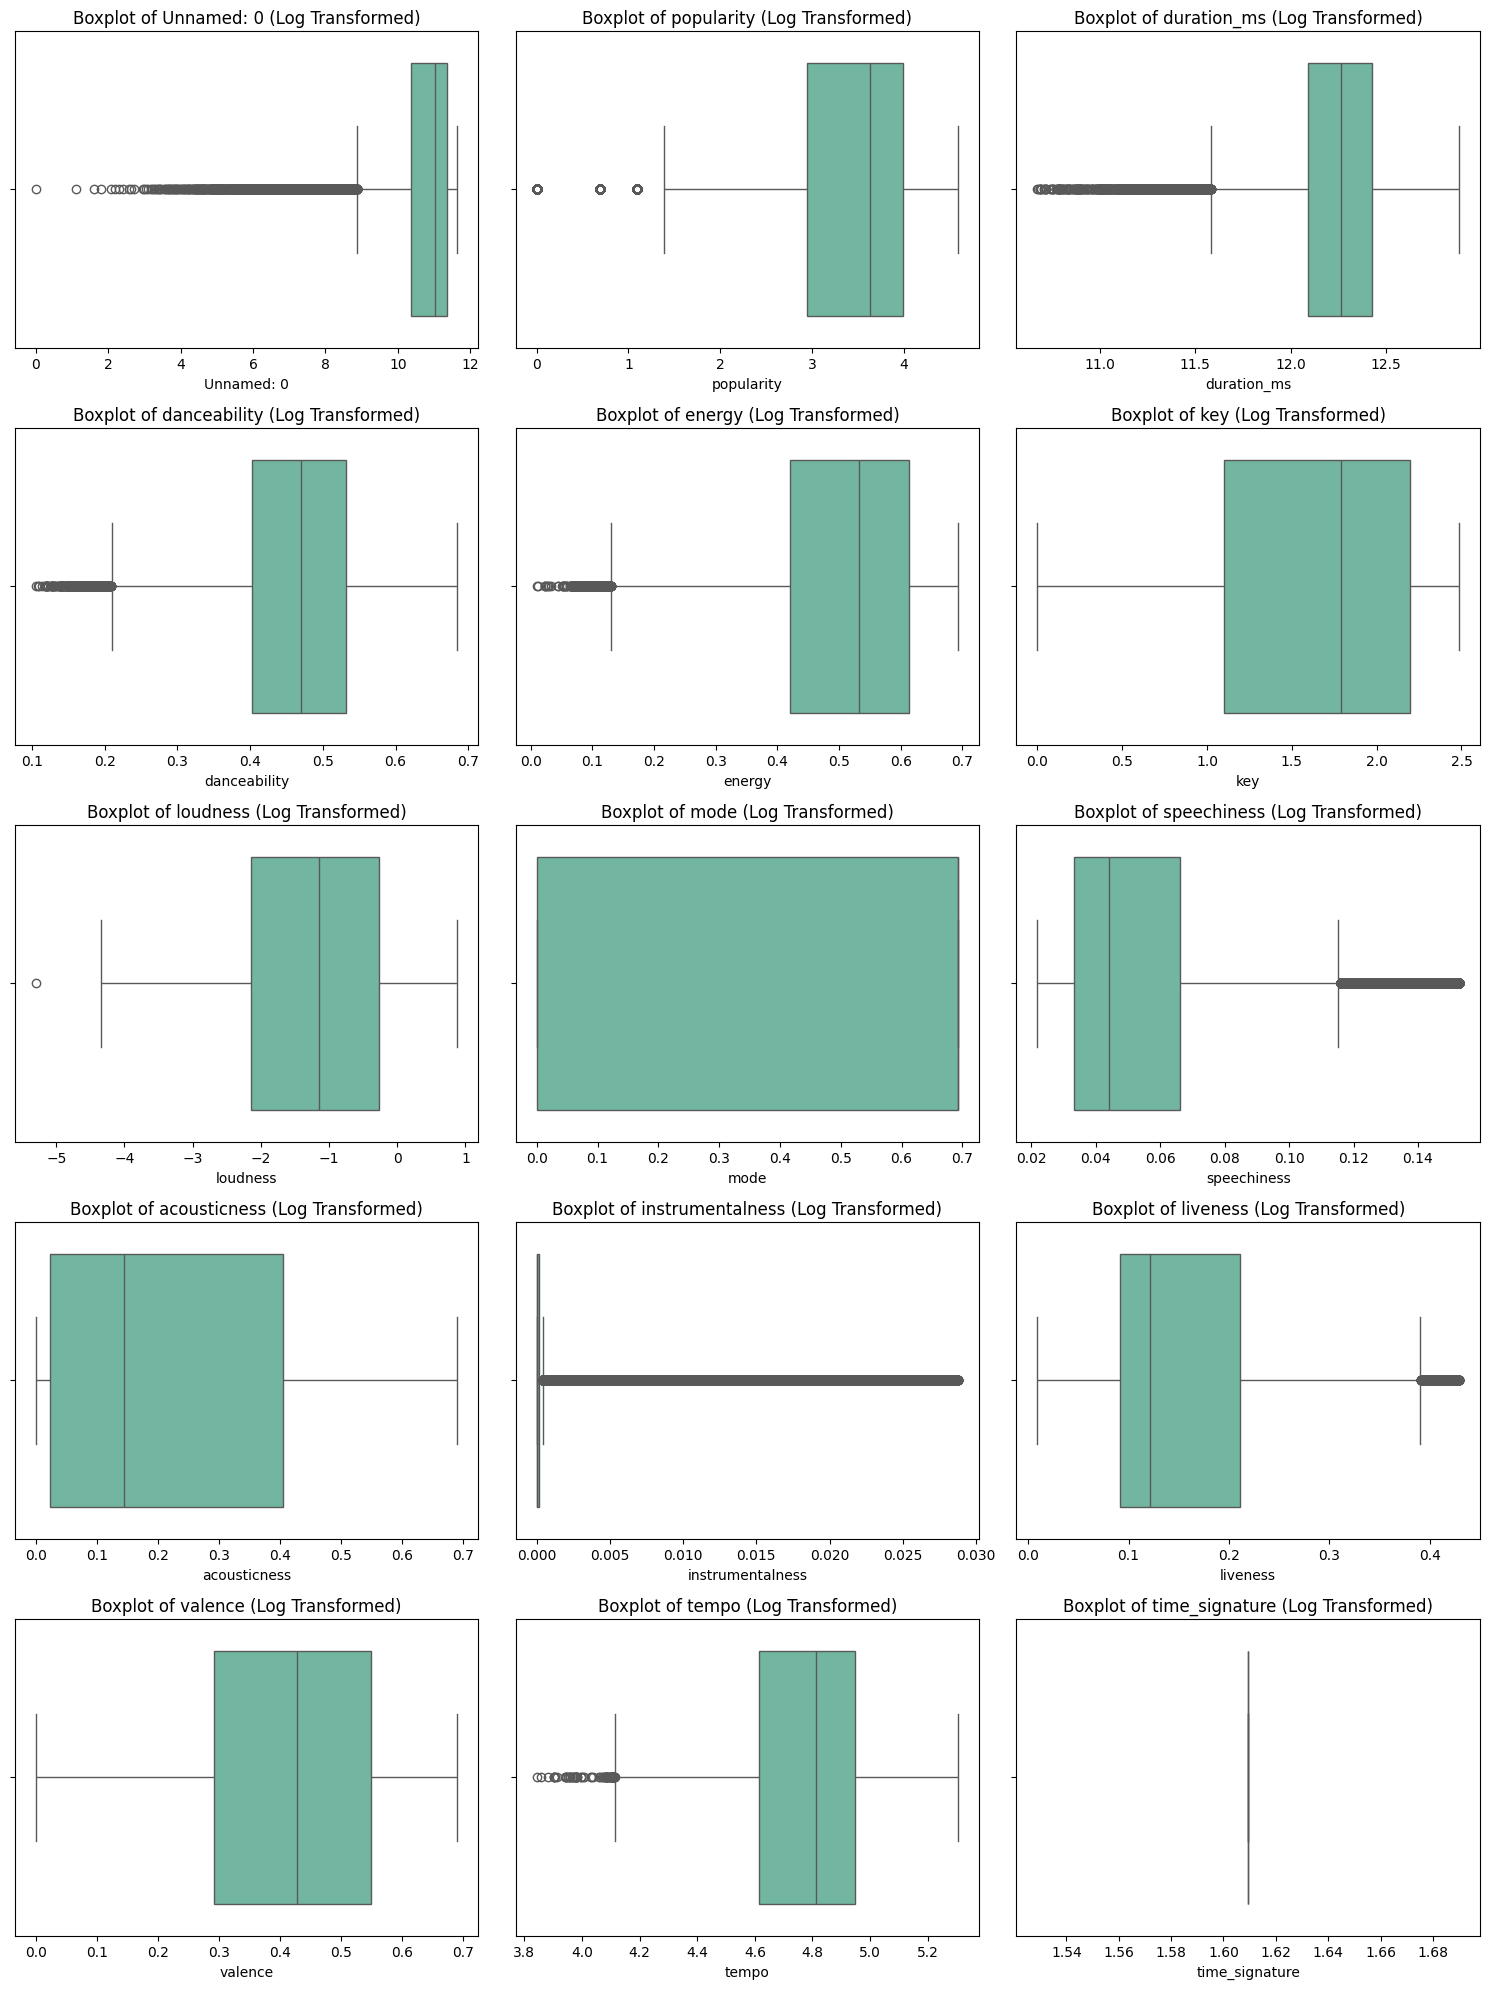

In [15]:
# Memilih hanya kolom numerik untuk penanganan outlier
df_numeric = df_cleaned.select_dtypes(include=['number'])

# Menangani outlier menggunakan metode IQR
df_no_outliers = df_numeric.copy()
for column in df_no_outliers.columns:
    Q1 = df_no_outliers[column].quantile(0.25)
    Q3 = df_no_outliers[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_no_outliers = df_no_outliers[(df_no_outliers[column] >= lower_bound) & (df_no_outliers[column] <= upper_bound)]

# Menerapkan transformasi log pada kolom numerik (log1p untuk menghindari log(0))
df_transformed = df_no_outliers.copy()
for column in df_transformed.columns:
    df_transformed[column] = np.log1p(df_transformed[column])

# Visualisasi boxplot
num_features = len(df_transformed.columns)
cols = 3
rows = math.ceil(num_features / cols)

plt.figure(figsize=(5 * cols, 4 * rows))
for i, column in enumerate(df_transformed.columns):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(x=df_transformed[column], palette='Set2')
    plt.title(f'Boxplot of {column} (Log Transformed)')
    plt.xlabel(column)
plt.tight_layout()
plt.show()

In [16]:
# Hapus kolom 'Unnamed: 0'
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Ubah kolom boolean ke numerik
if 'explicit' in df.columns and df['explicit'].dtype == 'bool':
    df['explicit'] = df['explicit'].astype(int)

# Cetak daftar kolom yang tersisa
print("Kolom yang tersisa dalam dataset:")
print(df.columns.tolist())

Kolom yang tersisa dalam dataset:
['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


In [17]:
# Imputasi missing values untuk kolom numerik dengan median
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numerical_cols] = df[numerical_cols].apply(lambda x: x.fillna(x.median()), axis=0)

# Imputasi missing values untuk kolom kategorikal dengan mode
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].apply(lambda x: x.fillna(x.mode()[0]), axis=0)

In [18]:
# Cek apakah masih ada missing values
print("Missing Values setelah Imputasi :")
print(df.isnull().sum())

# Pastikan semua missing values sudah 0
assert df.isnull().sum().sum() == 0, "Masih ada missing values!"

Missing Values setelah Imputasi :
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [19]:
# Tampilkan 5 baris pertama dari data yang telah dibersihkan
print("Contoh data hasil cleaning:")
print(df.head())

Contoh data hasil cleaning:
                 track_id                 artists  \
0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666         0   
1            Ghost - Acoustic          55       149610         0   
2              To Begin Again          57       210826         0   
3  Can't Help Falling In Love          71   

In [20]:
df_final = df.drop_duplicates()
df_final.to_csv("dataset_bersih.csv", index=False)
print("Data akhir telah disimpan ke 'dataset_bersih.csv'.")

Data akhir telah disimpan ke 'dataset_bersih.csv'.


## Data Normalisasi

In [21]:
# Load data
df = pd.read_csv("/content/dataset_bersih.csv")

# Mengasumsikan df adalah dataframe yang sudah ada
df = df.copy()

# Konversi kolom boolean ke integer (True = 1, False = 0)
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

# Inisialisasi scaler Min-Max untuk normalisasi fitur
scaler = MinMaxScaler()

# Memilih hanya kolom numerik (termasuk hasil konversi boolean)
df_numeric = df.select_dtypes(include=['number'])

# Salin dataframe untuk normalisasi
df_normalized = df.copy()

# Terapkan Min-Max Scaling hanya pada kolom numerik
df_normalized[df_numeric.columns] = scaler.fit_transform(df_numeric)

# Tampilkan hasil normalisasi
print(df_normalized.head())

                 track_id                 artists  \
0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy        0.73     0.044043       0.0   
1            Ghost - Acoustic        0.55     0.028566       0.0   
2              To Begin Again        0.57     0.040255       0.0   
3  Can't Help Falling In Love        0.71     0.038557       0.0   
4   

In [22]:
# Simpan hasil akhir ke CSV
df_final.to_csv("dataset_final.csv", index=False)
print("Data akhir telah disimpan ke 'dataset_final.csv'.")

Data akhir telah disimpan ke 'dataset_final.csv'.


# **LABELLING KELAS (SUKA DAN TIDAK SUKA)**

In [23]:
# Klasifikasi berdasarkan popularitas: Suka dan  Tidak Suka
def classify_popularity(score):
    if score >= 40:
        return 'Suka'
    else:
        return 'Tidak Suka'

df['popularity_class'] = df['popularity'].apply(classify_popularity)

popularity_counts = df['popularity_class'].value_counts().reindex(['Suka', 'Tidak Suka'])

In [24]:
# Menampilkan jumlah data per kelas
popularity_counts = df['popularity_class'].value_counts().reindex(['Suka', 'Tidak Suka'])
print("\nDistribusi Kelas:\n", popularity_counts)


Distribusi Kelas:
 popularity_class
Suka          48549
Tidak Suka    65001
Name: count, dtype: int64


In [25]:
# Menyiapkan data fitur (gunakan semua kolom kecuali target)
features = df.drop(columns=['popularity_class']).select_dtypes(include=['number']).columns  # Hanya kolom numerik
X = df[features]

In [26]:
# Label Encoding untuk target variabel (popularity_class)
y = df['popularity_class']

# Inisialisasi LabelEncoder untuk encoding label
le = LabelEncoder()

# Terapkan label encoding pada variabel target
y_encoded = le.fit_transform(y)

In [27]:
# Cek hasil encoding
print("\nMapping Label:")
for i, label in enumerate(le.classes_):
    print(f"{label} -> {i}")


Mapping Label:
Suka -> 0
Tidak Suka -> 1


# **Feature Selection**

## Tanpa Feature Selection

In [28]:
print("\nFitur yang digunakan (tanpa seleksi fitur):")
print(features.tolist())


Fitur yang digunakan (tanpa seleksi fitur):
['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


## Memakai Chi-Square Test

In [29]:
# Normalisasi ulang untuk X karena chi2 butuh nilai non-negatif
scaler_chi2 = MinMaxScaler()
X_scaled = scaler_chi2.fit_transform(X)

# Seleksi fitur menggunakan Chi-Square Test
selector = SelectKBest(score_func=chi2, k=9)
X_selected = selector.fit_transform(X_scaled, y_encoded)

# Mendapatkan fitur yang dipilih (True/False)
selected_features = pd.Series(selector.get_support(), index=features)

# Tampilkan hasil fitur yang dipilih
print("Fitur yang dipilih oleh chi2:")
print(selected_features[selected_features].index.tolist())


Fitur yang dipilih oleh chi2:
['popularity', 'explicit', 'danceability', 'energy', 'mode', 'speechiness', 'instrumentalness', 'liveness', 'valence']


## Memakai SFS (Sequential Forward Selection)

Feature Selection SFS  ini akan dievaluasi secara langsung pada bagian evaluasi masing-masing model. Silakan jalankan kode pada bagian tersebut untuk melihat performanya.

# **KNN (K-NEAREST NEIGHBORS)**


## Evaluasi Model tanpa Chi2


=== Classification Report - KNN (Tanpa Feature Selection) ===
              precision    recall  f1-score   support

  Tidak Suka       0.92      0.94      0.93     19328
        Suka       0.96      0.94      0.95     26092

    accuracy                           0.94     45420
   macro avg       0.94      0.94      0.94     45420
weighted avg       0.94      0.94      0.94     45420



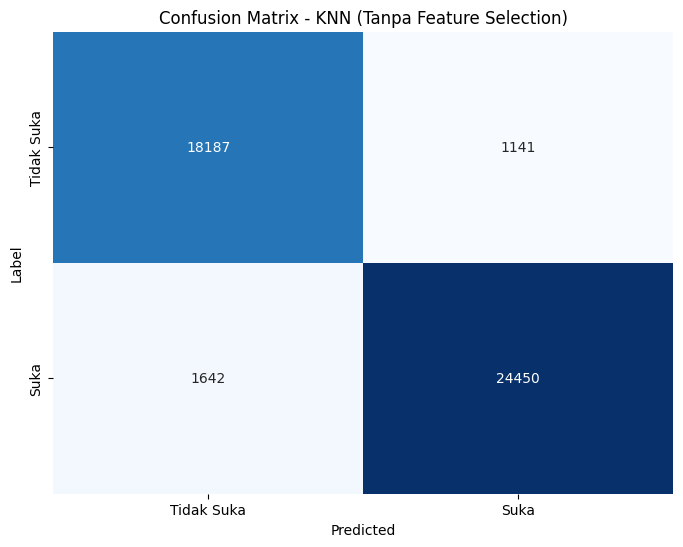

In [41]:
# Membaca dataset dari path lokal di Google Colab
df = pd.read_csv('/content/dataset_final.csv')

# Fitur yang digunakan (tanpa melakukan feature selection)
features = ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
            'key', 'loudness', 'mode', 'speechiness', 'acousticness',
            'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']

X = df[features]

# Encode label target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Normalisasi fitur
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split data 60:40
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.4, random_state=42)

# Inisialisasi dan latih model KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Prediksi
y_pred = knn.predict(X_test)

# Classification report
print("\n=== Classification Report - KNN (Tanpa Feature Selection) ===")
print(classification_report(y_test, y_pred, target_names=["Tidak Suka", "Suka"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Tidak Suka", "Suka"],
            yticklabels=["Tidak Suka", "Suka"],
            cbar=False)
plt.title("Confusion Matrix - KNN (Tanpa Feature Selection)")
plt.xlabel("Predicted")
plt.ylabel("Label")
plt.show()

## Evaluasi Model dengan Chi2


=== Laporan Klasifikasi KNN (Dengan Feature Selection Chi2) ===
              precision    recall  f1-score   support

  Tidak Suka       0.95      0.97      0.96     19328
        Suka       0.98      0.97      0.97     26092

    accuracy                           0.97     45420
   macro avg       0.96      0.97      0.97     45420
weighted avg       0.97      0.97      0.97     45420



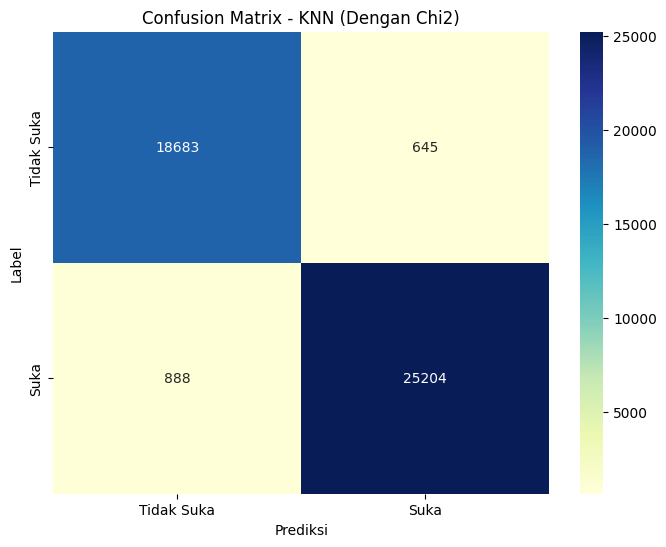

In [47]:
# Membaca dataset
df = pd.read_csv('/content/dataset_final.csv')

# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Fitur yang dipilih berdasarkan Chi-Square (Chi2)
features_chi = ['popularity', 'explicit', 'danceability', 'energy',
                'mode', 'speechiness', 'instrumentalness', 'liveness', 'valence']

# Ambil hanya fitur yang dipilih
X_chi = df[features_chi]

# Normalisasi fitur
scaler = MinMaxScaler()
X_chi_scaled = scaler.fit_transform(X_chi)

# Split data 60:40
X_train, X_test, y_train, y_test = train_test_split(X_chi_scaled, y_encoded, test_size=0.4, random_state=42)

# Inisialisasi dan latih model KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Evaluasi Model
y_pred = knn.predict(X_test)

print("\n=== Laporan Klasifikasi KNN (Dengan Feature Selection Chi2) ===")
print(classification_report(y_test, y_pred, target_names=["Tidak Suka", "Suka"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=["Tidak Suka", "Suka"],
            yticklabels=["Tidak Suka", "Suka"])
plt.title("Confusion Matrix - KNN (Dengan Chi2)")
plt.xlabel("Prediksi")
plt.ylabel("Label")
plt.show()


## Evaluasi Model dengan SFS (Sequential Forward Selection)

In [40]:
# Load data
df = pd.read_csv('/content/dataset_final.csv')

# Buat kolom 'popularity_class' setelah membaca data
def classify_popularity(score):
    if score >= 40:
        return 'Suka'
    else:
        return 'Tidak Suka'

df['popularity_class'] = df['popularity'].apply(classify_popularity)

# Pilih fitur dan target
X = df[features]
y = df["popularity_class"]

# Normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.4, random_state=42)

# Inisialisasi model
model = KNeighborsClassifier(n_neighbors=5)

# Inisialisasi dan jalankan SFS (forward selection)
sfs = SequentialFeatureSelector(model, n_features_to_select=9, direction='forward')
sfs.fit(X_train, y_train)

# Tampilkan fitur terpilih
selected_features = [features[i] for i in range(len(features)) if sfs.get_support()[i]]
print("Fitur KNN (SFS):", selected_features)


Fitur KNN (SFS): ['popularity', 'explicit', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'time_signature']



=== Classification Report - KNN (SFS) ===
              precision    recall  f1-score   support

        Suka       0.97      0.97      0.97     19328
  Tidak Suka       0.98      0.98      0.98     26092

    accuracy                           0.97     45420
   macro avg       0.97      0.97      0.97     45420
weighted avg       0.97      0.97      0.97     45420

Akurasi: 0.9742
Macro F1-score: 0.9737


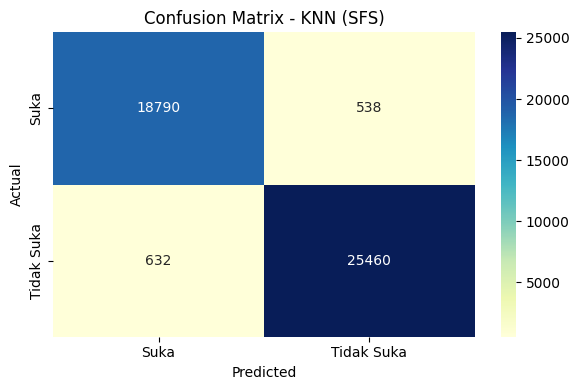

In [39]:
# Ambil data hanya dengan fitur terpilih
X_selected = df[selected_features]
X_scaled_selected = scaler.fit_transform(X_selected)

# Split ulang untuk evaluasi akhir
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_scaled_selected, y, test_size=0.4, random_state=42)

# Latih ulang model dengan fitur terpilih
model.fit(X_train_sel, y_train_sel)
y_pred = model.predict(X_test_sel)

# Evaluasi model
print("\n=== Classification Report - KNN (SFS) ===")
print(classification_report(y_test_sel, y_pred))

accuracy = accuracy_score(y_test_sel, y_pred)
f1 = f1_score(y_test_sel, y_pred, average='macro')
print(f"Akurasi: {accuracy:.4f}")
print(f"Macro F1-score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test_sel, y_pred, labels=["Suka", "Tidak Suka"])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=["Suka", "Tidak Suka"],
            yticklabels=["Suka", "Tidak Suka"])
plt.title("Confusion Matrix - KNN (SFS)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# **LOGISTIC REGRESSION**

## Evaluasi Model tanpa Chi2


=== Classification Report - Logistic Regression (Tanpa Feature Selection) ===
              precision    recall  f1-score   support

  Tidak Suka       1.00      1.00      1.00     19328
        Suka       1.00      1.00      1.00     26092

    accuracy                           1.00     45420
   macro avg       1.00      1.00      1.00     45420
weighted avg       1.00      1.00      1.00     45420



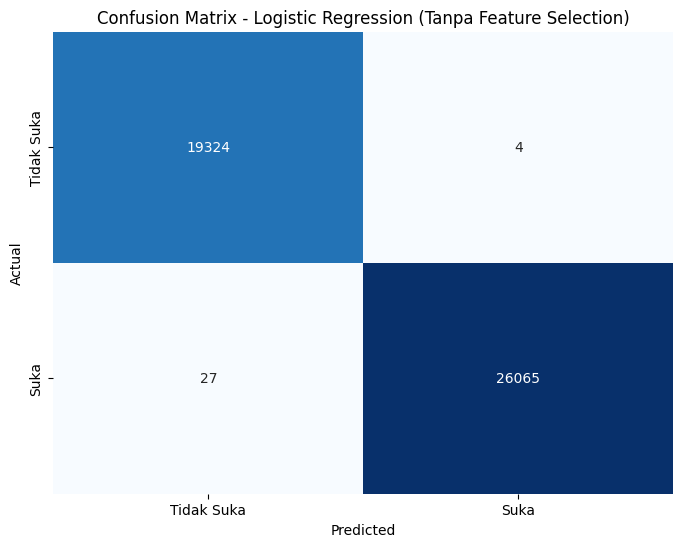

In [52]:
# Membaca dataset
df = pd.read_csv('/content/dataset_final.csv')

# Daftar fitur yang digunakan (tanpa feature selection)
features = ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
            'key', 'loudness', 'mode', 'speechiness', 'acousticness',
            'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']

# Ambil data fitur
X = df[features]  # Pastikan df sudah didefinisikan sebelumnya

# Target variable (pastikan y_encoded sudah disiapkan, misalnya hasil LabelEncoder)
y = y_encoded

# Normalisasi fitur
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split data 60:40
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.4, random_state=42)

# Inisialisasi model Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)

# Training model
logreg.fit(X_train, y_train)

# Prediksi
y_pred = logreg.predict(X_test)

# Evaluasi performa model
print("\n=== Classification Report - Logistic Regression (Tanpa Feature Selection) ===")
print(classification_report(y_test, y_pred, target_names=["Tidak Suka", "Suka"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Tidak Suka", "Suka"],
            yticklabels=["Tidak Suka", "Suka"],
            cbar=False)
plt.title("Confusion Matrix - Logistic Regression (Tanpa Feature Selection)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Evaluasi Model dengan Chi2


=== Classification Report - Logistic Regression (dengan Feature Selection CHI2) ===
              precision    recall  f1-score   support

  Tidak Suka       1.00      1.00      1.00     19328
        Suka       1.00      1.00      1.00     26092

    accuracy                           1.00     45420
   macro avg       1.00      1.00      1.00     45420
weighted avg       1.00      1.00      1.00     45420



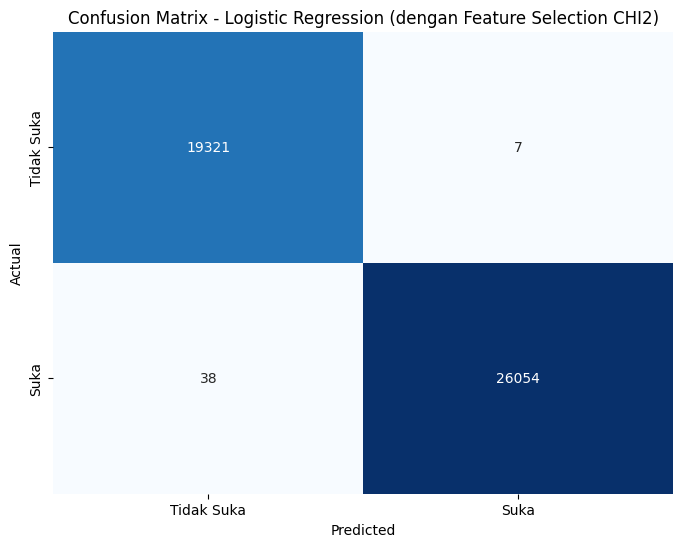

In [57]:
# Membaca dataset
df = pd.read_csv('/content/dataset_final.csv')

# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Fitur yang dipilih berdasarkan Chi-Square (Chi2)
features_chi = ['popularity', 'explicit', 'danceability', 'energy',
                'mode', 'speechiness', 'instrumentalness', 'liveness', 'valence']

# Ambil hanya fitur yang dipilih
X_chi = df[features_chi]

# Normalisasi fitur
scaler = MinMaxScaler()
X_chi_scaled = scaler.fit_transform(X_chi)

# Split data 60:40
X_train, X_test, y_train, y_test = train_test_split(X_chi_scaled, y_encoded, test_size=0.4, random_state=42)

# Inisialisasi model Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)

# Training model
logreg.fit(X_train, y_train)

# Prediksi
y_pred = logreg.predict(X_test)

# Evaluasi performa model
print("\n=== Classification Report - Logistic Regression (dengan Feature Selection CHI2) ===")
print(classification_report(y_test, y_pred, target_names=["Tidak Suka", "Suka"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Tidak Suka", "Suka"],
            yticklabels=["Tidak Suka", "Suka"],
            cbar=False)
plt.title("Confusion Matrix - Logistic Regression (dengan Feature Selection CHI2)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Evaluasi Model dengan SFS (Sequential Forward Selection)

In [42]:
# Load data
df = pd.read_csv('/content/dataset_final.csv')


# Buat kolom 'popularity_class' setelah membaca data
def classify_popularity(score):
    if score >= 40:
        return 'Suka'
    else:
        return 'Tidak Suka'

df['popularity_class'] = df['popularity'].apply(classify_popularity)

# Pilih fitur dan target
X = df[features]
y = df["popularity_class"]

# Normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.4, random_state=42)

# Inisialisasi model
model = LogisticRegression(max_iter=1000, random_state=42)

# Inisialisasi dan jalankan SFS (forward selection)
sfs = SequentialFeatureSelector(model, n_features_to_select=9, direction='forward')
sfs.fit(X_train, y_train)

# Tampilkan fitur terpilih
selected_features = [features[i] for i in range(len(features)) if sfs.get_support()[i]]
print("Fitur Logistic Reggression (SFS):", selected_features)


Fitur Logistic Reggression (SFS): ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness']



=== Classification Report - KLogistic Regression (SFS) ===
              precision    recall  f1-score   support

        Suka       1.00      1.00      1.00     19328
  Tidak Suka       1.00      1.00      1.00     26092

    accuracy                           1.00     45420
   macro avg       1.00      1.00      1.00     45420
weighted avg       1.00      1.00      1.00     45420

Akurasi: 1.0000
Macro F1-score: 1.0000


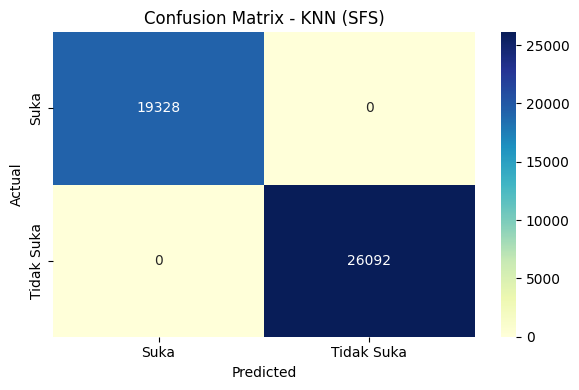

In [43]:
# Ambil data hanya dengan fitur terpilih
X_selected = df[selected_features]
X_scaled_selected = scaler.fit_transform(X_selected)

# Split ulang untuk evaluasi akhir
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_scaled_selected, y, test_size=0.4, random_state=42)

# Latih ulang model dengan fitur terpilih
model.fit(X_train_sel, y_train_sel)
y_pred = model.predict(X_test_sel)

# Evaluasi model
print("\n=== Classification Report - KLogistic Regression (SFS) ===")
print(classification_report(y_test_sel, y_pred))

accuracy = accuracy_score(y_test_sel, y_pred)
f1 = f1_score(y_test_sel, y_pred, average='macro')
print(f"Akurasi: {accuracy:.4f}")
print(f"Macro F1-score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test_sel, y_pred, labels=["Suka", "Tidak Suka"])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=["Suka", "Tidak Suka"],
            yticklabels=["Suka", "Tidak Suka"])
plt.title("Confusion Matrix - KNN (SFS)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# **RANDOM FOREST**

## Evaluasi Model tanpa Chi2


=== Classification Report - Random Forest (Tanpa Feature Selection) ===
              precision    recall  f1-score   support

  Tidak Suka       1.00      1.00      1.00     19328
        Suka       1.00      1.00      1.00     26092

    accuracy                           1.00     45420
   macro avg       1.00      1.00      1.00     45420
weighted avg       1.00      1.00      1.00     45420



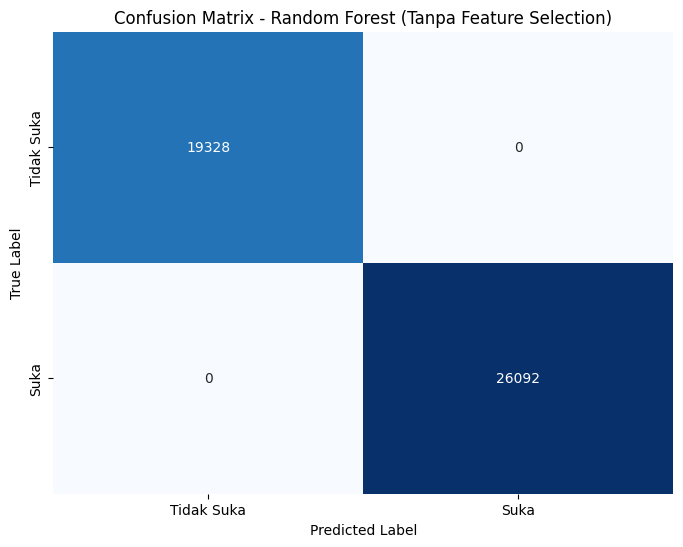

In [58]:
# Membaca dataset
df = pd.read_csv('/content/dataset_final.csv')

# Daftar fitur yang digunakan (tanpa feature selection)
features = ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
            'key', 'loudness', 'mode', 'speechiness', 'acousticness',
            'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']

# Ambil data fitur
X = df[features]  # Pastikan df sudah didefinisikan sebelumnya

# Target variable (pastikan y_encoded sudah disiapkan, misalnya hasil LabelEncoder)
y = y_encoded

# Normalisasi fitur
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split data 60:40
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.4, random_state=42)

# Inisialisasi model Logistic Regression
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Training model
rf_model.fit(X_train, y_train)

# Prediksi
y_pred = rf_model.predict(X_test)

# Evaluasi performa model
print("\n=== Classification Report - Random Forest (Tanpa Feature Selection) ===")
print(classification_report(y_test, y_pred, target_names=["Tidak Suka", "Suka"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Tidak Suka", "Suka"],
            yticklabels=["Tidak Suka", "Suka"],
            cbar=False)
plt.title("Confusion Matrix - Random Forest (Tanpa Feature Selection)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Evaluasi Model dengan Chi2


=== Classification Report - Random Forest (dengan Feature Selection CHI2) ===
              precision    recall  f1-score   support

  Tidak Suka       1.00      1.00      1.00     19328
        Suka       1.00      1.00      1.00     26092

    accuracy                           1.00     45420
   macro avg       1.00      1.00      1.00     45420
weighted avg       1.00      1.00      1.00     45420



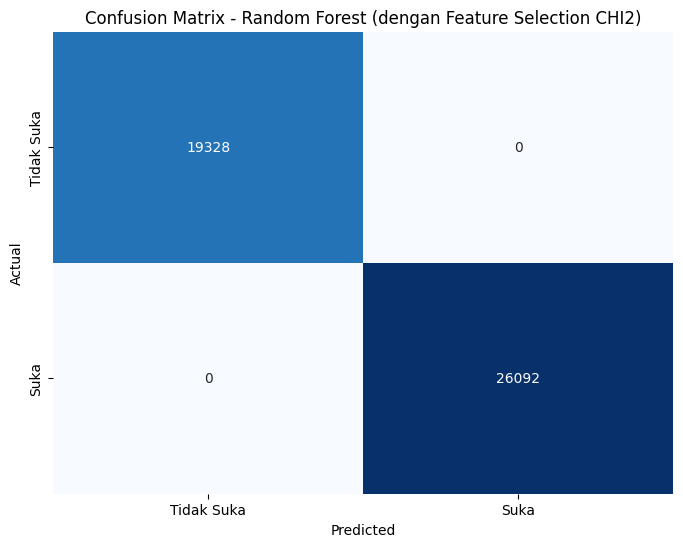

In [60]:
# Membaca dataset
df = pd.read_csv('/content/dataset_final.csv')

# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Fitur yang dipilih berdasarkan Chi-Square (Chi2)
features_chi = ['popularity', 'explicit', 'danceability', 'energy',
                'mode', 'speechiness', 'instrumentalness', 'liveness', 'valence']

# Ambil hanya fitur yang dipilih
X_chi = df[features_chi]

# Normalisasi fitur
scaler = MinMaxScaler()
X_chi_scaled = scaler.fit_transform(X_chi)

# Split data 60:40
X_train, X_test, y_train, y_test = train_test_split(X_chi_scaled, y_encoded, test_size=0.4, random_state=42)

# Inisialisasi model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Training model
rf_model.fit(X_train, y_train)

# Prediksi
y_pred = rf_model.predict(X_test)

# Evaluasi performa model
print("\n=== Classification Report - Random Forest (dengan Feature Selection CHI2) ===")
print(classification_report(y_test, y_pred, target_names=["Tidak Suka", "Suka"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Tidak Suka", "Suka"],
            yticklabels=["Tidak Suka", "Suka"],
            cbar=False)
plt.title("Confusion Matrix - Random Forest (dengan Feature Selection CHI2)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Evaluasi Model dengan SFS (Sequential Forward Selection)

In [44]:
# Load data
df = pd.read_csv('/content/dataset_final.csv')

# Buat kolom 'popularity_class' setelah membaca data
def classify_popularity(score):
    if score >= 40:
        return 'Suka'
    else:
        return 'Tidak Suka'

df['popularity_class'] = df['popularity'].apply(classify_popularity)

# Pilih fitur dan target
X = df[features]
y = df["popularity_class"]

# Normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.4, random_state=42)

# Inisialisasi model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Inisialisasi dan jalankan SFS (forward selection)
sfs = SequentialFeatureSelector(model, n_features_to_select=9, direction='forward')
sfs.fit(X_train, y_train)

# Tampilkan fitur terpilih
selected_features = [features[i] for i in range(len(features)) if sfs.get_support()[i]]
print("Fitur Random Forest (SFS):", selected_features)


Fitur Random Forest (SFS): ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness']



=== Classification Report - Random Forest (SFS) ===
              precision    recall  f1-score   support

        Suka       1.00      1.00      1.00     19328
  Tidak Suka       1.00      1.00      1.00     26092

    accuracy                           1.00     45420
   macro avg       1.00      1.00      1.00     45420
weighted avg       1.00      1.00      1.00     45420

Akurasi: 1.0000
Macro F1-score: 1.0000


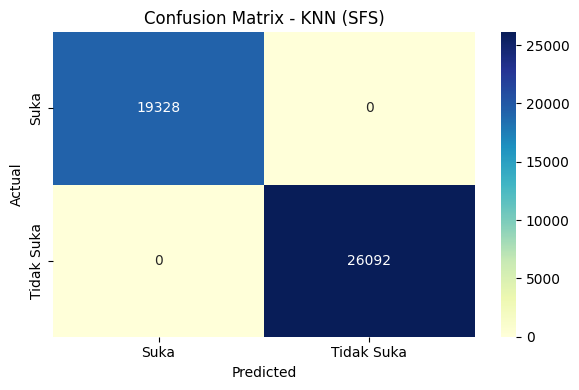

In [45]:
# Ambil data hanya dengan fitur terpilih
X_selected = df[selected_features]
X_scaled_selected = scaler.fit_transform(X_selected)

# Split ulang untuk evaluasi akhir
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_scaled_selected, y, test_size=0.4, random_state=42)

# Latih ulang model dengan fitur terpilih
model.fit(X_train_sel, y_train_sel)
y_pred = model.predict(X_test_sel)

# Evaluasi model
print("\n=== Classification Report - Random Forest (SFS) ===")
print(classification_report(y_test_sel, y_pred))

accuracy = accuracy_score(y_test_sel, y_pred)
f1 = f1_score(y_test_sel, y_pred, average='macro')
print(f"Akurasi: {accuracy:.4f}")
print(f"Macro F1-score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test_sel, y_pred, labels=["Suka", "Tidak Suka"])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=["Suka", "Tidak Suka"],
            yticklabels=["Suka", "Tidak Suka"])
plt.title("Confusion Matrix - KNN (SFS)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# **CONTOH INSTANCE SALAH DAN BENAR**

## Tanpa Feature Selection

In [51]:
# Daftar fitur yang digunakan (tanpa feature selection)
feature_names = ['popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
                 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
                 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']

# Ubah X_test (numpy array) menjadi DataFrame
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# Buat DataFrame hasil prediksi
results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

# Tambahkan kolom kategori prediksi: Benar atau Salah
results_df['Category'] = results_df.apply(
    lambda row: 'Benar' if row['Actual'] == row['Predicted'] else 'Salah', axis=1
)

# Reset index agar bisa digabungkan
X_test_df = X_test_df.reset_index(drop=True)
results_df = results_df.reset_index(drop=True)

# Gabungkan fitur dan hasil prediksi
combined_df = pd.concat([X_test_df, results_df], axis=1)

# Tampilkan semua kolom
pd.set_option('display.max_columns', None)

# Contoh Prediksi Benar
print("Contoh Prediksi Benar:")
benar_df = combined_df[combined_df['Category'] == 'Benar']
if not benar_df.empty:
    display(benar_df.sample(1))
else:
    print("Tidak ada prediksi yang benar.")

# Contoh Prediksi Salah
print("\n Contoh Prediksi Salah:")
salah_df = combined_df[combined_df['Category'] == 'Salah']
if not salah_df.empty:
    display(salah_df.sample(1))
else:
    print("Tidak ada prediksi yang salah.")



Contoh Prediksi Benar:


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,Actual,Predicted,Category
30766,1.286843,-0.206113,3.268716,-0.36925,-0.295121,-0.367816,0.211802,-1.327163,-0.478194,-0.942308,-0.498882,-0.672115,-1.557499,0.158781,0.221658,Suka,Suka,Benar



 Contoh Prediksi Salah:
Tidak ada prediksi yang salah.


## Menggunakan Feature Seelection (CHI2)

In [56]:
# Daftar fitur hasil seleksi Chi-Square
features_chi = ['popularity', 'explicit', 'danceability', 'energy',
                'mode', 'speechiness', 'instrumentalness', 'liveness', 'valence']

from sklearn.model_selection import train_test_split

# Ambil ulang X berdasarkan features_chi
X_chi = df[features_chi]
y = df['popularity_class']  # Sesuaikan dengan target kamu

# Split ulang
X_train_chi, X_test_chi, y_train, y_test = train_test_split(X_chi, y, test_size=0.2, random_state=42)

# Prediksi ulang (misalnya dengan model KNN yang sudah dilatih ulang dengan X_train_chi)
y_pred = model.predict(X_test_chi)

# Lanjut ke bagian gabung hasil prediksi:
X_test_df = pd.DataFrame(X_test_chi, columns=features_chi)

results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results_df['Category'] = results_df.apply(
    lambda row: 'Benar' if row['Actual'] == row['Predicted'] else 'Salah', axis=1
)

X_test_df = X_test_df.reset_index(drop=True)
results_df = results_df.reset_index(drop=True)

combined_df = pd.concat([X_test_df, results_df], axis=1)

# Tampilkan
pd.set_option('display.max_columns', None)

print("Contoh Prediksi Benar:")
benar_df = combined_df[combined_df['Category'] == 'Benar']
if not benar_df.empty:
    display(benar_df.sample(1))
else:
    print("Tidak ada prediksi yang benar.")

print("\n Contoh Prediksi Salah:")
salah_df = combined_df[combined_df['Category'] == 'Salah']
if not salah_df.empty:
    display(salah_df.sample(1))
else:
    print("Tidak ada prediksi yang salah.")



/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Contoh Prediksi Benar:


,popularity,explicit,danceability,energy,mode,speechiness,instrumentalness,liveness,valence,Actual,Predicted,Category
10888,42,0,0.547,0.752,1,0.0254,0.00005,0.102,0.559,Suka,Suka,Benar



 Contoh Prediksi Salah:


,popularity,explicit,danceability,energy,mode,speechiness,instrumentalness,liveness,valence,Actual,Predicted,Category
22051,22,0,0.426,0.0506,1,0.0643,0.935,0.117,0.228,Tidak Suka,Suka,Salah


In [58]:
# Daftar fitur hasil seleksi SFS
features_sfs = ['popularity', 'duration_ms', 'explicit',
                'danceability', 'energy', 'key',
                'loudness', 'mode', 'speechiness']

from sklearn.model_selection import train_test_split

# Ambil ulang X berdasarkan features_sfs
X_sfs = df[features_sfs]
y = df['popularity_class']  # Sesuaikan dengan target kamu

# Split ulang
X_train_sfs, X_test_sfs, y_train, y_test = train_test_split(X_sfs, y, test_size=0.2, random_state=42)

# Melatih model Random Forest (jika belum)
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_sfs, y_train)

# Prediksi ulang dengan model RF
y_pred = model_rf.predict(X_test_sfs)

# Buat DataFrame hasil prediksi dan fitur uji
X_test_df = pd.DataFrame(X_test_sfs, columns=features_sfs)

results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

# Kategorikan prediksi: Benar / Salah
results_df['Category'] = results_df.apply(
    lambda row: 'Benar' if row['Actual'] == row['Predicted'] else 'Salah', axis=1
)

# Reset index untuk penggabungan
X_test_df = X_test_df.reset_index(drop=True)
results_df = results_df.reset_index(drop=True)

# Gabungkan data fitur dan hasil prediksi
combined_df = pd.concat([X_test_df, results_df], axis=1)

# Tampilkan hasil prediksi benar dan salah
pd.set_option('display.max_columns', None)

print("Contoh Prediksi Benar:")
benar_df = combined_df[combined_df['Category'] == 'Benar']
if not benar_df.empty:
    display(benar_df.sample(1))
else:
    print("Tidak ada prediksi yang benar.")

print("\nContoh Prediksi Salah:")
salah_df = combined_df[combined_df['Category'] == 'Salah']
if not salah_df.empty:
    display(salah_df.sample(1))
else:
    print("Tidak ada prediksi yang salah.")


Contoh Prediksi Benar:


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,Actual,Predicted,Category
3668,50,199411,1,0.69,0.72,7,-5.601,1,0.285,Suka,Suka,Benar



Contoh Prediksi Salah:
Tidak ada prediksi yang salah.


## Visualisasi Pohon Keputusan Random Forest

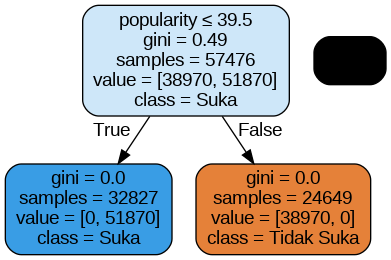

In [59]:
from sklearn.tree import export_graphviz
from sklearn.ensemble import RandomForestClassifier
from IPython.display import Image
import matplotlib.pyplot as plt
import graphviz
import pydotplus
from io import StringIO

# Ambil salah satu pohon dari random forest
estimator = model_rf.estimators_[0]  # ambil pohon pertama

# Buat dot file dari decision tree
dot_data = StringIO()
export_graphviz(
    estimator,
    out_file=dot_data,
    feature_names=features_sfs,   # ganti dengan daftar fitur yang digunakan (misalnya SFS)
    class_names=['Tidak Suka', 'Suka'],  # sesuaikan label
    filled=True,
    rounded=True,
    special_characters=True
)

# Render menjadi gambar
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
image = Image(graph.create_png())

# Tampilkan gambar di notebook
display(image)
